# Mini Project 2
Nama: Faraday Barr Fatahillah

Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

#### Background

Cardio Vascular Disease (CVD) merupakan penyakit yang sangat mematikan dengan [tahun 2021 terdapat 20.5 Juta kematian dan terjadi di negara dengan pemasukan menengah ke bawah.](https://pmc.ncbi.nlm.nih.gov/articles/PMC10809869/) Penyebab utama kematian dari CVD adalah penyakit jantung iskemik dan stroke, yang disebabkan oleh faktor risiko perilaku dan metabolik seperti penggunaan tembakau, alkohol, kurang aktivitas fisik, tekanan darah tinggi, dan kadar glukosa darah tinggi.

#### Problem Statements

1. Kurangnya fasilitas intervensi lebih awal untuk prediksi dini.
2. Metode tradisional bergantung pada interpretasi manual.

#### Objective

1. Melakukan analisis statistika dan eksplorasi data terhadap dataset CVD untuk memahami distribusi data, pola, dan faktor-faktor yang paling berpengaruh.
2. Membangun dan membandingkan model Machine Learning (ML) untuk evaluasi efektivitas dalam memprediksi CVD dan melakukan evaluasi metrik accuracy, precision, F1-score, dan ROC-AUC.
3. Melakukan hyperparameter tuning untuk mendapatkan performa terbaik.
4. Menghasilkan insight yang dapat membantu tenaga medis atau masyarakat dalam pengambilan keputusan klinis cepat.

#### Import Library

In [61]:
#All library needed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from xgboost import XGBClassifier


#### Load Dataset

In [62]:
#Load dataset
df = pd.read_csv('cardio_train.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


#### Clean Dataset

In [64]:
df.isna().sum().sort_values(ascending=False)

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Label per Column:
1. 'age': dalam hari (harus di ubah dulu ke tahun)
2. 'gender': '1' = women, '2' = men (akan diubah menjadi men = 1 dan women = 0)
3. 'height': tinggi dalam cm 
4. 'weight': berat badan dalam kg
5. 'ap_hi': Systolic blood pressure
6. 'ap_lo': Diastolic blood pressure
7. 'cholesterol': Kadar kolesterol kategorik dengan '1' = normal, '2' = di atas normal, '3' = jauh di atas normal
8. 'gluc': Kadar glukosa kategorik dengan '1' = normal, '2' = di atas normal, '3' = jauh di atas normal
9. 'smoke': merokok atau tidak (binary)
10. 'alco': minum atau tidak (binary)
11. 'active': ada aktivitas fisik atau tidak (binary)
12. 'cardio': Target, apakah memiliki penyakitnya atau tidak

In [65]:
df = df.drop(columns=['id'])
df['age'] = (df['age']/365.65).astype('int64')

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0


In [66]:
df['gender'] = df['gender'] - 1

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,47,0,156,56.0,100,60,1,1,0,0,0,0


#### Statistik Deskriptif

In [67]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,52.745529,0.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.754869,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,0.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,1.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [68]:
numerik = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in numerik:
    print(f'Mean {col}: {df[col].mean()}')
    print(f'Median {col}: {df[col].median()}')
    print(f'Mode {col}: {df[col].mode()[0]}')
    print(f'Std {col}: {df[col].std()}')
    print(f'Q1 {col}: {df[col].quantile(0.25)}')
    print(f'Q3 {col}: {df[col].quantile(0.75)}')
    print(f'IQR {col}: {df[col].quantile(0.75) - df[col].quantile(0.25)}')
    print('')

Mean age: 52.74552857142857
Median age: 53.0
Mode age: 55
Std age: 6.754868856394437
Q1 age: 48.0
Q3 age: 58.0
IQR age: 10.0

Mean height: 164.35922857142856
Median height: 165.0
Mode height: 165
Std height: 8.210126364538038
Q1 height: 159.0
Q3 height: 170.0
IQR height: 11.0

Mean weight: 74.20569
Median weight: 72.0
Mode weight: 65.0
Std weight: 14.395756678511379
Q1 weight: 65.0
Q3 weight: 82.0
IQR weight: 17.0

Mean ap_hi: 128.8172857142857
Median ap_hi: 120.0
Mode ap_hi: 120
Std ap_hi: 154.01141945609137
Q1 ap_hi: 120.0
Q3 ap_hi: 140.0
IQR ap_hi: 20.0

Mean ap_lo: 96.63041428571428
Median ap_lo: 80.0
Mode ap_lo: 80
Std ap_lo: 188.47253029639026
Q1 ap_lo: 80.0
Q3 ap_lo: 90.0
IQR ap_lo: 10.0



In [69]:
df['ap_hi'].min()

np.int64(-150)

In [70]:
df['ap_hi'].unique()

array([  110,   140,   130,   150,   100,   120,   145,   170,   135,
         125,    90,   180,   160,   133,   190,    80,   122,   169,
         126,   158,   200,    14,   123,    70,   161,   147,   115,
         137,   153,    11,   148,   105,   220,   119,   141,   165,
         164,    12,   124,   172,   902,   162,   906,   117,   134,
         166,   210,   176,   116,    10,   121,    16,   112,   159,
         113,   118,   155,   142,   131,   157,   136,   146,   138,
        -100,   909,   109,    85,   106,   129,    93,     7,    95,
         179,   156,   168,   132,   104,   103,   178,   175,   128,
         151,    15,   139, 11500,   127,    17,   108,   144,   102,
           1,  1420,    13,   143,   701,   107,   184,   149,   167,
         114,   101,    60,  1500,   181,   171,   202,  -115,   111,
         907,    20,   188,   185,   163,   173,   154,   177,  -140,
         174,  -120, 14020,  1400,   240,   191,   197,  1620,   152,
          96,   199,

In [71]:
df['ap_hi'] = df['ap_hi'].abs().astype('str').str[:3].astype('int64')
df['ap_hi'].unique()

array([110, 140, 130, 150, 100, 120, 145, 170, 135, 125,  90, 180, 160,
       133, 190,  80, 122, 169, 126, 158, 200,  14, 123,  70, 161, 147,
       115, 137, 153,  11, 148, 105, 220, 119, 141, 165, 164,  12, 124,
       172, 902, 162, 906, 117, 134, 166, 210, 176, 116,  10, 121,  16,
       112, 159, 113, 118, 155, 142, 131, 157, 136, 146, 138, 909, 109,
        85, 106, 129,  93,   7,  95, 179, 156, 168, 132, 104, 103, 178,
       175, 128, 151,  15, 139, 127,  17, 108, 144, 102,   1,  13, 143,
       701, 107, 184, 149, 167, 114, 101,  60, 181, 171, 202, 111, 907,
        20, 188, 185, 163, 173, 154, 177, 174, 240, 191, 197, 152,  96,
       199, 193,  99, 196, 309, 401, 806, 230, 207, 215,  97,  24, 960,
       195, 187])

In [72]:
df.query('ap_hi == 16020')

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [73]:
df['ap_lo'] = df['ap_lo'].abs().astype('str').str[:3].astype('int64')
df['ap_lo'].unique()

array([ 80,  90,  70, 100,  60,  85,  89, 110,  65,  63,  79, 800, 120,
        50,  30, 109,  84, 103, 150,  91,  40,  73,  78,  75,  86,  87,
        82,  95,  69,  74,  97,  81,  83, 119,   0,  93, 105,  99,  77,
        59, 804, 140,  92, 104, 108, 125, 115,  68,  61, 106, 102,  94,
        66,  52, 170,  76, 160,  62,  96, 130, 113,  67, 910,  10,  88,
       902,   8, 112,  71,  72,  98, 208,  20, 802, 850, 708,  57, 101,
       901,  64, 117, 710,  45, 709,  58, 111, 809, 126, 107,   7, 180,
       121, 810, 570, 807,   6, 190, 114, 801,  53,   1, 118,  56, 182,
         9, 980, 820,  55, 900, 122, 680, 135, 700,  15,  54, 880, 870,
       585,  49, 602])

In [74]:
df.query('ap_hi == 11000')

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


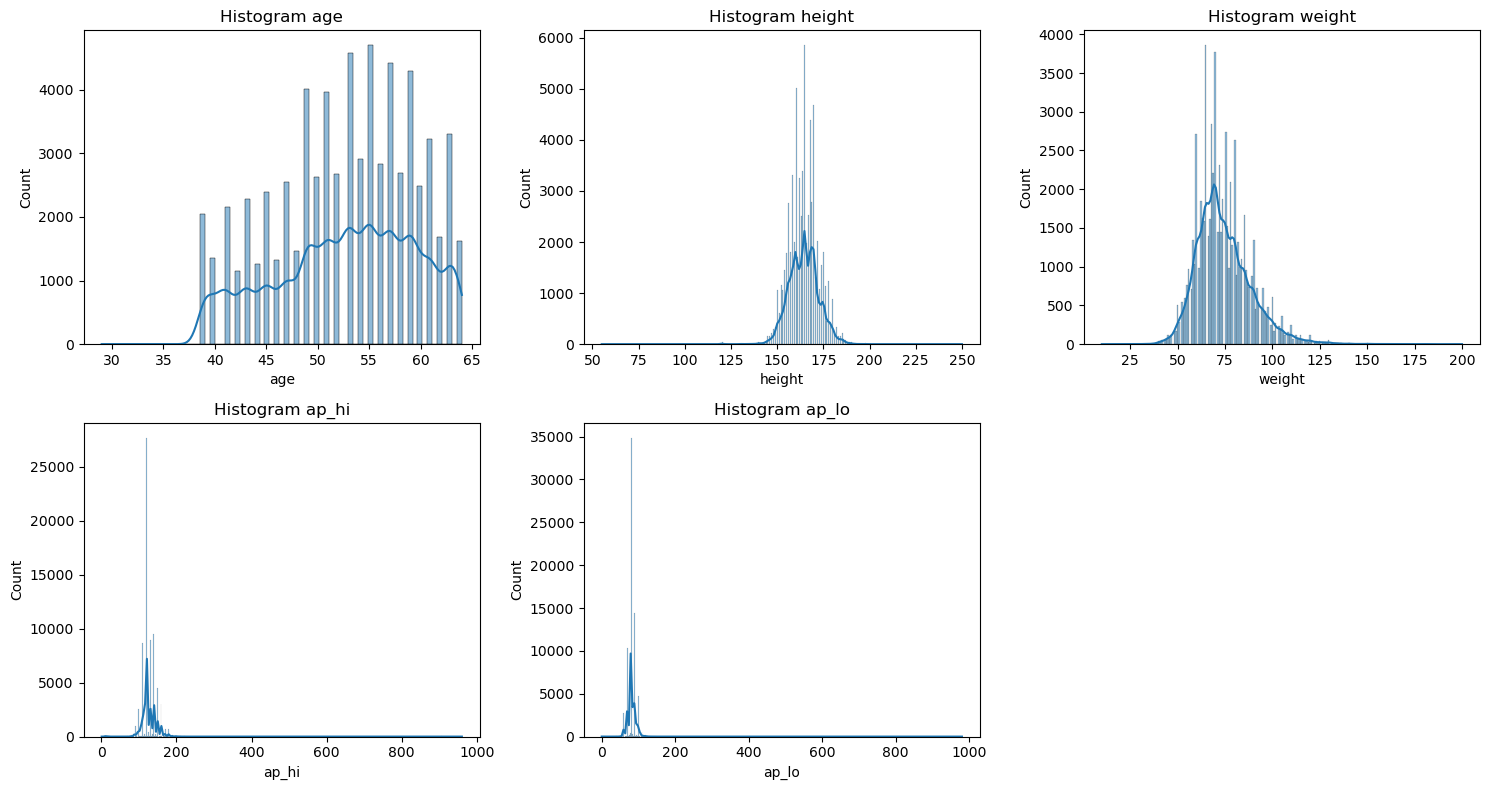

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerik):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram {col}')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

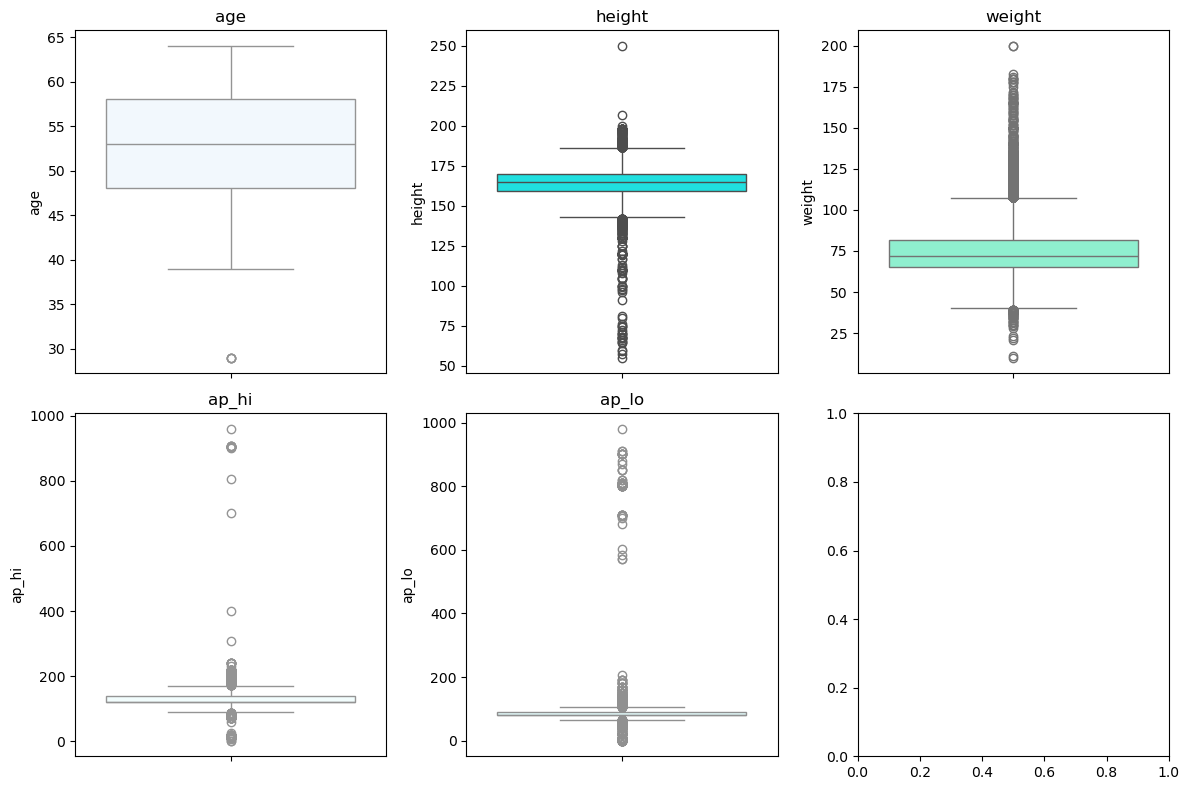

In [76]:
fig, ax = plt.subplots(2, 3 , figsize=(12,8))
ax = ax.flatten()

color = ['aliceblue', 'aqua', 'aquamarine', 'azure', 'lightcyan', 'lightskyblue']

for i, col in enumerate(numerik):
    sns.boxplot(data=df, y=col, ax=ax[i], color=color[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [77]:
X = df.drop(columns='cardio')
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_col = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
num_col = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo']

In [78]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, num_col),
        ('categorical', categorical_pipeline, cat_col)
    ],
    remainder='passthrough',
    verbose=True
)

In [79]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

[ColumnTransformer] ..... (1 of 2) Processing numerical, total=   0.1s
[ColumnTransformer] ... (2 of 2) Processing categorical, total=   0.0s


In [80]:
preprocessor.get_feature_names_out()

array(['numerical__age', 'numerical__gender', 'numerical__height',
       'numerical__weight', 'numerical__ap_hi', 'numerical__ap_lo',
       'categorical__cholesterol', 'categorical__gluc',
       'categorical__smoke', 'categorical__alco', 'categorical__active'],
      dtype=object)

In [81]:
X_train_preprocessed= pd.DataFrame(X_train_preprocessed, columns=preprocessor.get_feature_names_out())
X_test_preprocessed= pd.DataFrame(X_test_preprocessed, columns=preprocessor.get_feature_names_out())

In [82]:
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

data_train= pd.concat([X_train_preprocessed, y_train], axis=1)
data_test= pd.concat([X_test_preprocessed, y_test], axis=1)